# Configuration

In [1]:
%run _dev_setup.py

🔁 Autoreload is ON (IPython detected).
✅ Using winners_curse from: /Users/iamsikun/Desktop/research/winners-curse/src/winners_curse


In [8]:
import pickle
import json 
import random
import pandas as pd 
import numpy as np

from tqdm import tqdm

In [3]:
# visualization
import matplotlib.pyplot as plt
import seaborn as sns

# visualization params
# label size
tick_label_size = 12
legend_label_size = 12
axis_label_size = 14
title_size = 18
# font
plt.rcParams['font.family'] = 'serif'

# model label map 
model_label_map = {
    'plugin': 'Plugin', 
    'standard_bootstrap': 'Standard Bootstrap', 
    'mn_bootstrap': 'm-out-of-n Bootstrap', 
    'num_bootstrap': 'Numerical Bootstrap'
}

In [4]:
from sklearn.linear_model import LogisticRegression, Lasso

In [10]:
import winners_curse.ab_test as ab_test
import winners_curse.targeting as tgt
from winners_curse.dgp import ABTest
from winners_curse.variables import * 
from winners_curse.analysis import * 

# A/B Testing

## Fixed vs. Random Param DGP

### Fixed param DGP

In [128]:
optimization_params = {
    'rank_and_select': {
        'optimizer': rct.select_higher_effect,
        'params': {}, 
        'display_name': 'Rank and Select'
    }, 
}

dgp_params = {
    'n_experiments': 1, 
    'base_effects': [PointMass(1), PointMass(1.1)],
    'noise_vars': [UnivariateGaussian(0, std=1), UnivariateGaussian(0, std=1)],
    'dgp_seed': 0
}

# dgp_params = {
#     'n_experiments': 1, 
#     'base_effects': [PointMass(0.1), PointMass(0.11)],
#     'response_type': 'bernoulli', 
#     'dgp_seed': 0
# }


data_params = {'sample_size': 100}

experiment_params = {'n_repeats': 500, 'fixed_params': True}

estimators_dict = {
    'bayes_normal': {
        'estimator': rct.bayes_estimate,
        'params': {'prior': 'normal', 'prior_mean': 0, 'prior_std': 1},
        'display_name': 'Bayesian (Normal)'
    },  
    'eb_normal': {
        'estimator': rct.empirical_bayes_estimate,
        'params': {'prior': 'normal', 'prior_orientation': 'treatment'},
        'display_name': 'Empirical Bayesian (Normal)'
    }, 
    'eb_tweedies': {
        'estimator': rct.empirical_bayes_estimate,
        'params': {'prior': 'tweedies', 'dof': 3, 'bin_width': 0.2, 'prior_orientation': 'treatment'},
        'display_name': 'Empirical Bayesian (Tweedies)'
    }, 
    'eb_spike_slab': {
        'estimator': rct.empirical_bayes_estimate,
        'params': {'prior': 'spike_slab', 'pi': 0.5, 'prior_orientation': 'treatment'},
        'display_name': 'Empirical Bayesian (Spike-Slab)'
    },
    'standard_bootstrap': {
        'estimator': rct.bootstrap_correction_estimate, 
        'params': {'n_bootstraps': 500, 'bootstrap_method': 'standard', 'n_jobs': 1}, 
        'display_name': 'Standard Bootstrap', 
    }, 
    'm_out_of_n_bootstrap': {
        'estimator': rct.bootstrap_correction_estimate, 
        'params': {'n_bootstraps': 500, 'power': 0.95, 'bootstrap_method': 'm_out_of_n', 'n_jobs': 1}, 
        'display_name': 'm-out-of-n Bootstrap', 
    },
    'numerical_bootstrap': {
        'estimator': rct.bootstrap_correction_estimate, 
        'params': {'n_bootstraps': 500, 'power': -0.45, 'bootstrap_method': 'numerical', 'n_jobs': 1}, 
        'display_name': 'Numerical Bootstrap', 
    }, 
}

In [129]:
result_records = rct.repeated_experiment(
    optimization_params=optimization_params, 
    dgp_params=dgp_params, 
    data_params=data_params, 
    experiment_params=experiment_params, 
    estimators_dict=estimators_dict,
    verbose=True, 
    n_jobs=-1
)

wc_measures_dict = rct.calculate_winners_curse_measures(
    result_records=result_records, 
    optimization_params=optimization_params, 
    estimators_dict=estimators_dict, 
    data_params=data_params
)

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 10 concurrent workers.
/Users/iamsikun/miniforge3/lib/python3.9/site-packages/statsmodels/genmod/generalized_linear_model.py:1342: PerfectSeparationWarning: Perfect separation or prediction detected, parameter may not be identified
  warnings.warn(msg, category=PerfectSeparationWarning)


Running 500 experiments...


/Users/iamsikun/miniforge3/lib/python3.9/site-packages/statsmodels/genmod/generalized_linear_model.py:1342: PerfectSeparationWarning: Perfect separation or prediction detected, parameter may not be identified
  warnings.warn(msg, category=PerfectSeparationWarning)
/Users/iamsikun/miniforge3/lib/python3.9/site-packages/statsmodels/genmod/generalized_linear_model.py:1342: PerfectSeparationWarning: Perfect separation or prediction detected, parameter may not be identified
  warnings.warn(msg, category=PerfectSeparationWarning)
/Users/iamsikun/miniforge3/lib/python3.9/site-packages/statsmodels/genmod/generalized_linear_model.py:1342: PerfectSeparationWarning: Perfect separation or prediction detected, parameter may not be identified
  warnings.warn(msg, category=PerfectSeparationWarning)
/Users/iamsikun/miniforge3/lib/python3.9/site-packages/statsmodels/genmod/generalized_linear_model.py:1342: PerfectSeparationWarning: Perfect separation or prediction detected, parameter may not be identif

In [130]:
delta_tau = dgp_params['base_effects'][1].mean - dgp_params['base_effects'][0].mean

optimizer = 'rank_and_select'

val_true_avg = wc_measures_dict[f'{optimizer}_nc_val_true_avg']
val_true_se = wc_measures_dict[f'{optimizer}_nc_val_true_se']

print('Policy Value Estimates: ')
print(f' - True Value: {val_true_avg:.3f} ({val_true_se:.3f})')
for estimator in ['nc'] + list(estimators_dict.keys()):
    display_name = estimators_dict[estimator]['display_name'] if estimator != 'nc' else 'No Correction'

    val_est_avg = wc_measures_dict[f'{optimizer}_{estimator}_val_est_avg']
    val_est_se = wc_measures_dict[f'{optimizer}_{estimator}_val_est_se']

    print(f' - {display_name}: {val_est_avg:.3f} ({val_est_se:.3f})')
    
print('\nWinner\'s Curse')
for estimator in ['nc'] + list(estimators_dict.keys()):
    display_name = estimators_dict[estimator]['display_name'] if estimator != 'nc' else 'No Correction'

    wc_est_avg = wc_measures_dict[f'{optimizer}_{estimator}_wc_avg'] / delta_tau
    wc_est_se = wc_measures_dict[f'{optimizer}_{estimator}_wc_se'] / delta_tau

    print(f' - {display_name}: {wc_est_avg:.2%} ({wc_est_se:.2%})')

Policy Value Estimates: 
 - True Value: 1.076 (0.004)
 - No Correction: 1.120 (0.009)
 - Bayesian (Normal): 1.109 (0.009)
 - Empirical Bayesian (Normal): 1.084 (0.008)
 - Empirical Bayesian (Tweedies): 1.299 (0.037)
 - Empirical Bayesian (Spike-Slab): 1.083 (0.008)
 - Standard Bootstrap: 1.085 (0.010)
 - m-out-of-n Bootstrap: 1.078 (0.010)
 - Numerical Bootstrap: 1.076 (0.010)

Winner's Curse
 - No Correction: 43.15% (9.10%)
 - Bayesian (Normal): 32.22% (9.02%)
 - Empirical Bayesian (Normal): 7.13% (8.84%)
 - Empirical Bayesian (Tweedies): 205.77% (36.69%)
 - Empirical Bayesian (Spike-Slab): 6.90% (8.84%)
 - Standard Bootstrap: 8.39% (10.00%)
 - m-out-of-n Bootstrap: 1.29% (10.03%)
 - Numerical Bootstrap: -0.53% (10.24%)


### Random param DGP

In [137]:
optimization_params = {
    'rank_and_select': {
        'optimizer': rct.select_higher_effect,
        'params': {}, 
        'display_name': 'Rank and Select'
    }, 
}

dgp_params = {
    'n_experiments': 1, 
    'base_effects': [UnivariateGaussian(1, 0.1), UnivariateGaussian(1.1, 0.1)],
    'noise_vars': [UnivariateGaussian(0, std=1), UnivariateGaussian(0, std=1)],
    'dgp_seed': 0
}

# dgp_params = {
#     'n_experiments': 1, 
#     'base_effects': [UnivariateGaussian(0.1, 0.01), UnivariateGaussian(0.11, 0.01)],
#     'noise_vars': [UnivariateGaussian(0, std=1), UnivariateGaussian(0, std=1)],
#     'response_type': 'bernoulli', 
#     'dgp_seed': 0
# }

data_params = {'sample_size': 100}

experiment_params = {'n_repeats': 500, 'fixed_params': False}

estimators_dict = {
    'bayes_normal': {
        'estimator': rct.bayes_estimate,
        'params': {'prior': 'normal', 'prior_mean': 0, 'prior_std': 1},
        'display_name': 'Bayesian (Normal)'
    },  
    'eb_normal': {
        'estimator': rct.empirical_bayes_estimate,
        'params': {'prior': 'normal', 'prior_orientation': 'treatment'},
        'display_name': 'Empirical Bayesian (Normal)'
    }, 
    'eb_tweedies': {
        'estimator': rct.empirical_bayes_estimate,
        'params': {'prior': 'tweedies', 'dof': 3, 'bin_width': 0.2, 'prior_orientation': 'treatment'},
        'display_name': 'Empirical Bayesian (Tweedies)'
    }, 
    'eb_spike_slab': {
        'estimator': rct.empirical_bayes_estimate,
        'params': {'prior': 'spike_slab', 'pi': 0.5, 'prior_orientation': 'treatment'},
        'display_name': 'Empirical Bayesian (Spike-Slab)'
    },
    'standard_bootstrap': {
        'estimator': rct.bootstrap_correction_estimate, 
        'params': {'n_bootstraps': 500, 'bootstrap_method': 'standard', 'n_jobs': 1}, 
        'display_name': 'Standard Bootstrap', 
    }, 
    'm_out_of_n_bootstrap': {
        'estimator': rct.bootstrap_correction_estimate, 
        'params': {'n_bootstraps': 500, 'power': 0.95, 'bootstrap_method': 'm_out_of_n', 'n_jobs': 1}, 
        'display_name': 'm-out-of-n Bootstrap', 
    },
    'numerical_bootstrap': {
        'estimator': rct.bootstrap_correction_estimate, 
        'params': {'n_bootstraps': 500, 'power': -0.45, 'bootstrap_method': 'numerical', 'n_jobs': 1}, 
        'display_name': 'Numerical Bootstrap', 
    }, 
}

In [138]:
result_records = rct.repeated_experiment(
    optimization_params=optimization_params, 
    dgp_params=dgp_params, 
    data_params=data_params, 
    experiment_params=experiment_params, 
    estimators_dict=estimators_dict,
    verbose=True, 
    n_jobs=-1
)

wc_measures_dict = rct.calculate_winners_curse_measures(
    result_records=result_records, 
    optimization_params=optimization_params, 
    estimators_dict=estimators_dict, 
    data_params=data_params
)

Running 500 experiments...


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 10 concurrent workers.
/Users/iamsikun/miniforge3/lib/python3.9/site-packages/statsmodels/genmod/generalized_linear_model.py:1342: PerfectSeparationWarning: Perfect separation or prediction detected, parameter may not be identified
  warnings.warn(msg, category=PerfectSeparationWarning)
/Users/iamsikun/miniforge3/lib/python3.9/site-packages/statsmodels/genmod/generalized_linear_model.py:1342: PerfectSeparationWarning: Perfect separation or prediction detected, parameter may not be identified
  warnings.warn(msg, category=PerfectSeparationWarning)
/Users/iamsikun/miniforge3/lib/python3.9/site-packages/statsmodels/genmod/generalized_linear_model.py:1342: PerfectSeparationWarning: Perfect separation or prediction detected, parameter may not be identified
  warnings.warn(msg, category=PerfectSeparationWarning)
/Users/iamsikun/miniforge3/lib/python3.9/site-packages/statsmodels/genmod/generalized_linear_model.py:1342: PerfectSeparationWar

In [139]:
delta_tau = dgp_params['base_effects'][1].mean - dgp_params['base_effects'][0].mean

optimizer = 'rank_and_select'

val_true_avg = wc_measures_dict[f'{optimizer}_nc_val_true_avg']
val_true_se = wc_measures_dict[f'{optimizer}_nc_val_true_se']

print('Policy Value Estimates: ')
print(f' - True Value: {val_true_avg:.3f} ({val_true_se:.3f})')
for estimator in ['nc'] + list(estimators_dict.keys()):
    display_name = estimators_dict[estimator]['display_name'] if estimator != 'nc' else 'No Correction'

    val_est_avg = wc_measures_dict[f'{optimizer}_{estimator}_val_est_avg']
    val_est_se = wc_measures_dict[f'{optimizer}_{estimator}_val_est_se']

    print(f' - {display_name}: {val_est_avg:.3f} ({val_est_se:.3f})')

print('\nWinner\'s Curse')
for estimator in ['nc'] + list(estimators_dict.keys()):
    display_name = estimators_dict[estimator]['display_name'] if estimator != 'nc' else 'No Correction'

    wc_est_avg = wc_measures_dict[f'{optimizer}_{estimator}_wc_avg'] / delta_tau
    wc_est_se = wc_measures_dict[f'{optimizer}_{estimator}_wc_se'] / delta_tau

    print(f' - {display_name}: {wc_est_avg:.2%} ({wc_est_se:.2%})')

Policy Value Estimates: 
 - True Value: 1.107 (0.010)
 - No Correction: 1.141 (0.012)
 - Bayesian (Normal): 1.130 (0.012)
 - Empirical Bayesian (Normal): 1.104 (0.012)
 - Empirical Bayesian (Tweedies): 1.418 (0.053)
 - Empirical Bayesian (Spike-Slab): 1.104 (0.012)
 - Standard Bootstrap: 1.113 (0.013)
 - m-out-of-n Bootstrap: 1.106 (0.014)
 - Numerical Bootstrap: 1.106 (0.014)

Winner's Curse
 - No Correction: 34.22% (9.41%)
 - Bayesian (Normal): 23.09% (9.34%)
 - Empirical Bayesian (Normal): -3.53% (9.35%)
 - Empirical Bayesian (Tweedies): 271.41% (51.06%)
 - Empirical Bayesian (Spike-Slab): -3.74% (9.35%)
 - Standard Bootstrap: 5.68% (10.19%)
 - m-out-of-n Bootstrap: -0.82% (10.25%)
 - Numerical Bootstrap: -1.72% (10.40%)


## Positive vs. Negative Effects

In [9]:
result_dir = '../results/ab_test_bayesian_20251214_233052/'

with open(f'{result_dir}/results.pkl', 'rb') as f:
    snr_results: dict = pickle.load(f)

with open(f'{result_dir}/config.json', 'r') as f:
    snr_config: dict = json.load(f)

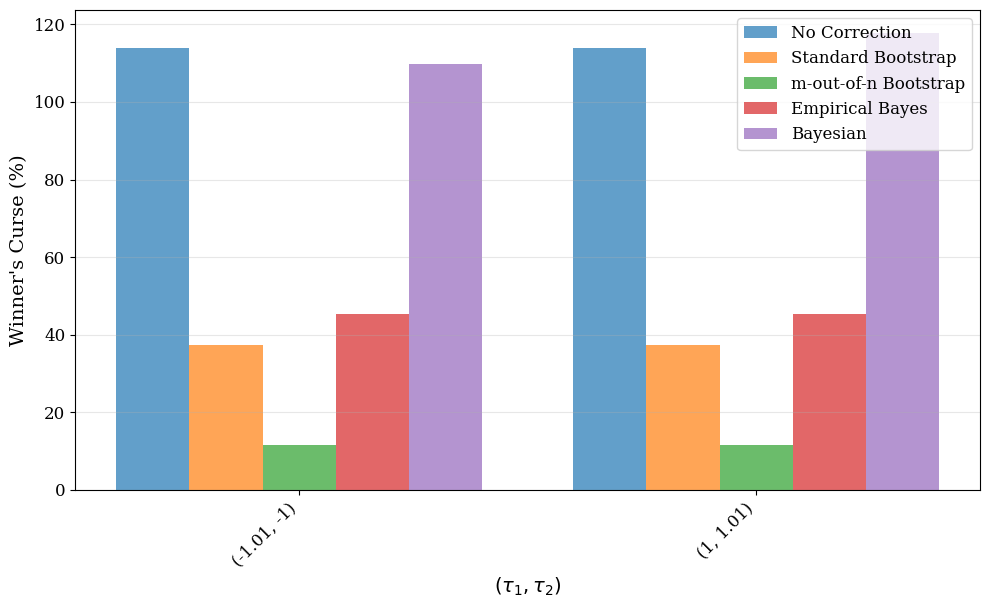

\begin{tabular}{lcc}
\toprule
$\Delta\tau$ & \multicolumn{2}{c}{0.010000} \\
$(\tau_0, \tau_1)$ & (1, 1.01) & (-1.01, -1) \\
\midrule
No Correction & \begin{tabular}[c]{@{}c@{}}113.85\%\\ (171.14\%)\end{tabular} & \begin{tabular}[c]{@{}c@{}}113.85\%\\ (171.14\%)\end{tabular} \\
Standard Bootstrap & \begin{tabular}[c]{@{}c@{}}37.49\%\\ (190.41\%)\end{tabular} & \begin{tabular}[c]{@{}c@{}}37.49\%\\ (190.41\%)\end{tabular} \\
m-out-of-n Bootstrap & \begin{tabular}[c]{@{}c@{}}11.65\%\\ (191.38\%)\end{tabular} & \begin{tabular}[c]{@{}c@{}}11.65\%\\ (191.38\%)\end{tabular} \\
Empirical Bayes & \begin{tabular}[c]{@{}c@{}}45.25\%\\ (161.82\%)\end{tabular} & \begin{tabular}[c]{@{}c@{}}45.25\%\\ (161.82\%)\end{tabular} \\
Bayesian & \begin{tabular}[c]{@{}c@{}}109.78\%\\ (171.07\%)\end{tabular} & \begin{tabular}[c]{@{}c@{}}117.81\%\\ (171.08\%)\end{tabular} \\
\bottomrule
\end{tabular}



$\Delta\tau$                          0.01            
$(\tau_0, \tau_1)$               (1, 1.01) (-1.01, -1)
Estimator            Statistic                        
No Correction        mean       113.847017  113.847017
                     std        171.137754  171.137754
Standard Bootstrap   mean        37.489670   37.489670
                     std        190.414139  190.414139
m-out-of-n Bootstrap mean        11.646514   11.646514
                     std        191.380563  191.380563
Empirical Bayes      mean        45.251898   45.251898
                     std        161.818207  161.818207
Bayesian             mean       109.781196  117.810542
                     std        171.071989  171.075062

In [17]:
plot_bernoulli_wc_comparison(
    snr_results, snr_config, 
    normalize=True
)

latex_table = generate_bernoulli_sum_stats_latex_table(
    snr_results, 
    snr_config, 
    normalize=True, 
    stats='mean'
)
print(latex_table)
stats_df = compute_bernoulli_sum_stats(
    snr_results,
    snr_config,
    normalize=True,
    stats_list=['mean', 'std'],
)
stats_df